# NLP processing

In [58]:
import numpy as np
import pandas as pd
import nltk
import jieba
from sudachipy import tokenizer
from sudachipy import dictionary
import re
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from scipy.stats import skew, kurtosis, mannwhitneyu


In [11]:
# import data

jp = pd.read_csv('data/jp.csv')

en = pd.read_csv('data/en.csv')

cn = pd.read_csv('data/cn.csv')



In [12]:
# read NRC emotion lexicon - available in multiple languages through google translate 

nrc = pd.read_csv('data/NRC-Emotion-Lexicon-v0.92-InManyLanguages-web.csv')


In [13]:
nrc = nrc[['English Word', 
                   'Chinese (simplified) Translation (Google Translate)',
                   'Japanese Translation (Google Translate)',
                   'Positive', 
                   'Negative', 
                   'Anger',
                   'Anticipation', 
                   'Disgust', 
                   'Fear', 
                   'Joy', 
                   'Sadness', 
                   'Surprise',
                   'Trust'
                   ]]
                

# Clean & Tokenize - ENG

In [14]:
en = en[['label', 'merged_text']]

# removes url, punctuations, converts to lower-case. 
def clean_for_emotion(text):
    import re
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    return text

en['cleaned_text'] = en['merged_text'].apply(clean_for_emotion)

# remove punctuations while preserving some, then tokenize 
from nltk.tokenize import word_tokenize

en['tokenized'] = en['cleaned_text'].apply(lambda x: re.findall(r"\b\w+(?:'\w+)?\b", x))

en.head()

,label,merged_text,cleaned_text,tokenized
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,law enforcement on high alert following threat...,"[law, enforcement, on, high, alert, following,..."
1,0,TITLE: BODY: Did they post their votes for H...,title: body: did they post their votes for h...,"[title, body, did, they, post, their, votes, f..."
2,0,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,unbelievable! obama’s attorney general says mo...,"[unbelievable, obama, s, attorney, general, sa..."
3,1,"Bobby Jindal, raised Hindu, uses story of Chri...","bobby jindal, raised hindu, uses story of chri...","[bobby, jindal, raised, hindu, uses, story, of..."
4,0,SATAN 2: Russia unvelis an image of its terrif...,satan 2: russia unvelis an image of its terrif...,"[satan, 2, russia, unvelis, an, image, of, its..."


In [56]:
print(en)

       label                                        merged_text  \
0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1          0   TITLE:  BODY: Did they post their votes for H...   
2          0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3          1  Bobby Jindal, raised Hindu, uses story of Chri...   
4          0  SATAN 2: Russia unvelis an image of its terrif...   
...      ...                                                ...   
72129      1  Russians steal research on Trump in hack of U....   
72130      0   WATCH: Giuliani Demands That Democrats Apolog...   
72131      1  Migrants Refuse To Leave Train At Refugee Camp...   
72132      1  Trump tussle gives unpopular Mexican leader mu...   
72133      0  Goldman Sachs Endorses Hillary Clinton For Pre...   

                                            cleaned_text  \
0      law enforcement on high alert following threat...   
1       title:  body: did they post their votes for h...   
2      unbeliev

# Clean & Tokenize - CN

In [15]:
cn = cn[['label', 'merged_text']]

# Clean URLs and remove punctuation
def clean_text_cn(text):
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove punctuation (both English and Chinese)
    text = re.sub(r"[^\w\s]", "", text)
    return text

cn['cleaned_text'] = cn['merged_text'].apply(clean_text_cn)

# Tokenize with jieba
cn['tokenized'] = cn['cleaned_text'].apply(jieba.lcut)

cn.head()


Building prefix dict from the default dictionary ...
Dumping model to file cache C:\Users\acl13\AppData\Local\Temp\jieba.cache
Loading model cost 0.507 seconds.
Prefix dict has been built successfully.


,label,merged_text,cleaned_text,tokenized
0,1,离婚窗口排长队,离婚窗口排长队,"[离婚, 窗口, 排长队, ]"
1,1,哈工程教学楼地下有数门“超电磁炮”,哈工程教学楼地下有数门超电磁炮,"[哈, 工程, 教学楼, 地下, 有数, 门超, 电磁炮, ]"
2,1,薯片胀袋是变质了,薯片胀袋是变质了,"[薯片, 胀, 袋, 是, 变质, 了, ]"
3,1,成本只要1毛钱的人造鸡蛋泛滥,成本只要1毛钱的人造鸡蛋泛滥,"[成本, 只要, 1, 毛钱, 的, 人造, 鸡蛋, 泛滥, ]"
4,1,隔着玻璃晒太阳能补钙,隔着玻璃晒太阳能补钙,"[隔, 着, 玻璃, 晒太阳, 能, 补钙, ]"


# Clean & Tokenize - JP

In [17]:
# An Experimental Evaluation of Japanese Tokenizers for Sentiment-Based Text Classification - Sudachi as a tokenizer that works well

jp = jp[['label', 'merged_text']]

jp['cleaned_text'] = jp['merged_text'].apply(clean_text_cn)

tokenizer_obj = dictionary.Dictionary().create()

jp.head()

,label,merged_text,cleaned_text
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...


In [18]:
mode = tokenizer.Tokenizer.SplitMode.C

jp['tokenized'] = jp['cleaned_text'].apply(lambda text: [m.surface() for m in tokenizer_obj.tokenize(text, mode)])

jp.head()

,label,merged_text,cleaned_text,tokenized
0,0,朝日新聞など各社の報道によれば、宅配便最大手「ヤマト運輸」が日本郵政公社を相手取り、大手コン...,朝日新聞など各社の報道によれば宅配便最大手ヤマト運輸が日本郵政公社を相手取り大手コンビニエン...,"[朝日新聞, など, 各社, の, 報道, に, よれ, ば, 宅配便, 最大手, ヤマト運..."
1,1,11月5日の各社報道によると、諫早湾干拓事業は諫早海人（諫早湾の「海」）に囲まれる大洋に位置...,11月5日の各社報道によると諫早湾干拓事業は諫早海人諫早湾の海に囲まれる大洋に位置することか...,"[11, 月, 5, 日, の, 各社, 報道, に, よる, と, 諫早湾, 干拓, 事業..."
2,1,産経新聞、中日新聞によると、2004年から2005年まで、この大会による3年おきの開催を、2...,産経新聞中日新聞によると2004年から2005年までこの大会による3年おきの開催を2006年...,"[産経新聞, 中日, 新聞, に, よる, と, 2004, 年, から, 2005, 年,..."
3,1,開催地のリオデジャネイロ市に対して、大会期間中のリオデジャネイロオリンピックに関する公式発表...,開催地のリオデジャネイロ市に対して大会期間中のリオデジャネイロオリンピックに関する公式発表は...,"[開催地, の, リオデジャネイロ, 市, に, 対し, て, 大会, 期間中, の, リオ..."
4,1,毎日新聞・時事通信によると、2006年2月13日には、グッドウィル・グッゲンハイム・アン・ハ...,毎日新聞時事通信によると2006年2月13日にはグッドウィルグッゲンハイムアンハルクを経営す...,"[毎日, 新聞, 時事, 通信, に, よる, と, 2006, 年, 2, 月, 13, ..."


In [19]:
type(jp['tokenized'].iloc[0])

list

# Emotion Detection 

looks up each token in the NRC dict, calculate a normalized emotion score for each news input.

In [20]:
nrc = nrc.rename(columns = {"English Word":'EN',
                      'Chinese (simplified) Translation (Google Translate)':'CN',
                      'Japanese Translation (Google Translate)':'JP'})
nrc.head()

,EN,CN,JP,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,aback,吓了一跳,あっけ,0,0,0,0,0,0,0,0,0,0
1,abacus,算盘,そろばん,0,0,0,0,0,0,0,0,0,1
2,abandon,放弃,捨てます,0,1,0,0,0,1,0,1,0,0
3,abandoned,弃,放棄されました,0,1,1,0,0,1,0,1,0,0
4,abandonment,放弃,放棄,0,1,1,0,0,1,0,1,1,0


In [21]:
EMOTIONS = ['Positive', 
            'Negative',
            'Anger',
            'Anticipation',
            'Disgust',
            'Fear',
            'Joy',
            'Sadness',
            'Surprise',
            'Trust']


LANGUAGES = {
    'English': (en, 'EN'),           
    'Chinese': (cn, 'CN'), 
    'Japanese': (jp, 'JP'),          
}

# build lookup table
def build_lookup(lex_df, word_col):
    """Build {word: {emotion: score}} dict for fast lookup."""
    sub = lex_df.dropna(subset=[word_col]).drop_duplicates(subset=[word_col], keep='first').set_index(word_col)[EMOTIONS]
    return sub.to_dict('index')


In [22]:
# scoring tokens
def score_tokens(token_list, lookup):
    """
    Given a list of tokens and a lookup dict,
    return a dict of normalised emotion scores (per token).
    Normalising by article length reduces bias from longer articles.
    """
    counts = {e: 0 for e in EMOTIONS}
    for token in token_list:
        if token in lookup:
            for e in EMOTIONS:
                counts[e] += lookup[token][e]

    n = len(token_list)
    return {e: counts[e]/n for e in EMOTIONS}

# add emotions score

def add_emo_score(df, lang_col):
    """Parse tokenized_text and add one column per emotion."""
    lookup = build_lookup(nrc, lang_col)
    df = df.copy()
    scores = df['tokenized'].apply(lambda x: score_tokens(x, lookup))
    scores_df = pd.DataFrame(scores.tolist(), index = df.index)
    df = pd.concat([df.drop(columns = ['tokenized']), scores_df], axis = 1)
    return df 



In [23]:
# apply to three languages

scored = {}

for lang, (df, col) in LANGUAGES.items():
    scored[lang] = add_emo_score(df, col)

scored

{'English':        label                                        merged_text  \
 0          0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
 1          0   TITLE:  BODY: Did they post their votes for H...   
 2          0  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
 3          1  Bobby Jindal, raised Hindu, uses story of Chri...   
 4          0  SATAN 2: Russia unvelis an image of its terrif...   
 ...      ...                                                ...   
 72129      1  Russians steal research on Trump in hack of U....   
 72130      0   WATCH: Giuliani Demands That Democrats Apolog...   
 72131      1  Migrants Refuse To Leave Train At Refugee Camp...   
 72132      1  Trump tussle gives unpopular Mexican leader mu...   
 72133      0  Goldman Sachs Endorses Hillary Clinton For Pre...   
 
                                             cleaned_text  Positive  Negative  \
 0      law enforcement on high alert following threat...  0.050420  0.061975   
 1       

In [41]:
# aggregate tables 

agg_tables = {}
for lang, df in scored.items():
    real = df[df['label'] == 0]
    fake = df[df['label'] == 1]
    
    rows = []
    for emotion in EMOTIONS:
        rows.append({
            'emotion': emotion,
            'real_mean': real[emotion].mean(),
            'real_sem': real[emotion].sem(),
            'fake_mean': fake[emotion].mean(),
            'fake_sem': fake[emotion].sem(),
            'diff (fake-real)': fake[emotion].mean() - real[emotion].mean()
        })
    
    tbl = pd.DataFrame(rows).set_index('emotion')
    agg_tables[lang] = tbl
    print(f"\n── {lang} ──")
    print(tbl.round(5))


── English ──
              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion                                                                 
Positive        0.05839   0.00015    0.06181   0.00012           0.00341
Negative        0.04035   0.00013    0.03635   0.00010          -0.00401
Anger           0.02094   0.00009    0.01829   0.00008          -0.00264
Anticipation    0.02372   0.00009    0.02370   0.00007          -0.00002
Disgust         0.01216   0.00007    0.00825   0.00004          -0.00391
Fear            0.02676   0.00011    0.02534   0.00010          -0.00142
Joy             0.01583   0.00008    0.01469   0.00006          -0.00114
Sadness         0.01739   0.00008    0.01542   0.00007          -0.00196
Surprise        0.01827   0.00009    0.01568   0.00007          -0.00259
Trust           0.04427   0.00014    0.05047   0.00013           0.00620

── Chinese ──
              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion              

In [42]:
print(agg_tables['English'].head())

              real_mean  real_sem  fake_mean  fake_sem  diff (fake-real)
emotion                                                                 
Positive       0.058394  0.000150   0.061809  0.000121          0.003414
Negative       0.040355  0.000126   0.036347  0.000104         -0.004008
Anger          0.020939  0.000090   0.018294  0.000078         -0.002645
Anticipation   0.023718  0.000087   0.023696  0.000074         -0.000022
Disgust        0.012159  0.000068   0.008250  0.000045         -0.003910


# Lookup match rate for CN & JP 

In [46]:
lookup_cn = build_lookup(nrc, 'CN')

def match_rate(df, lookup):
    def pct(tokens):
        matched = sum(1 for t in tokens if t in lookup)
        return matched / len(tokens) if tokens else 0
    return df['tokenized'].apply(pct).describe()

print(match_rate(cn, lookup_cn))

count    23789.000000
mean         0.285821
std          0.107457
min          0.000000
25%          0.218750
50%          0.285714
75%          0.350000
max          0.857143
Name: tokenized, dtype: float64


In [47]:
print(match_rate(jp, build_lookup(nrc, 'JP')))

count    13316.000000
mean         0.187642
std          0.044845
min          0.000000
25%          0.158672
50%          0.185567
75%          0.213257
max          0.733691
Name: tokenized, dtype: float64


# visualization - emotion across languages, real vs. fake

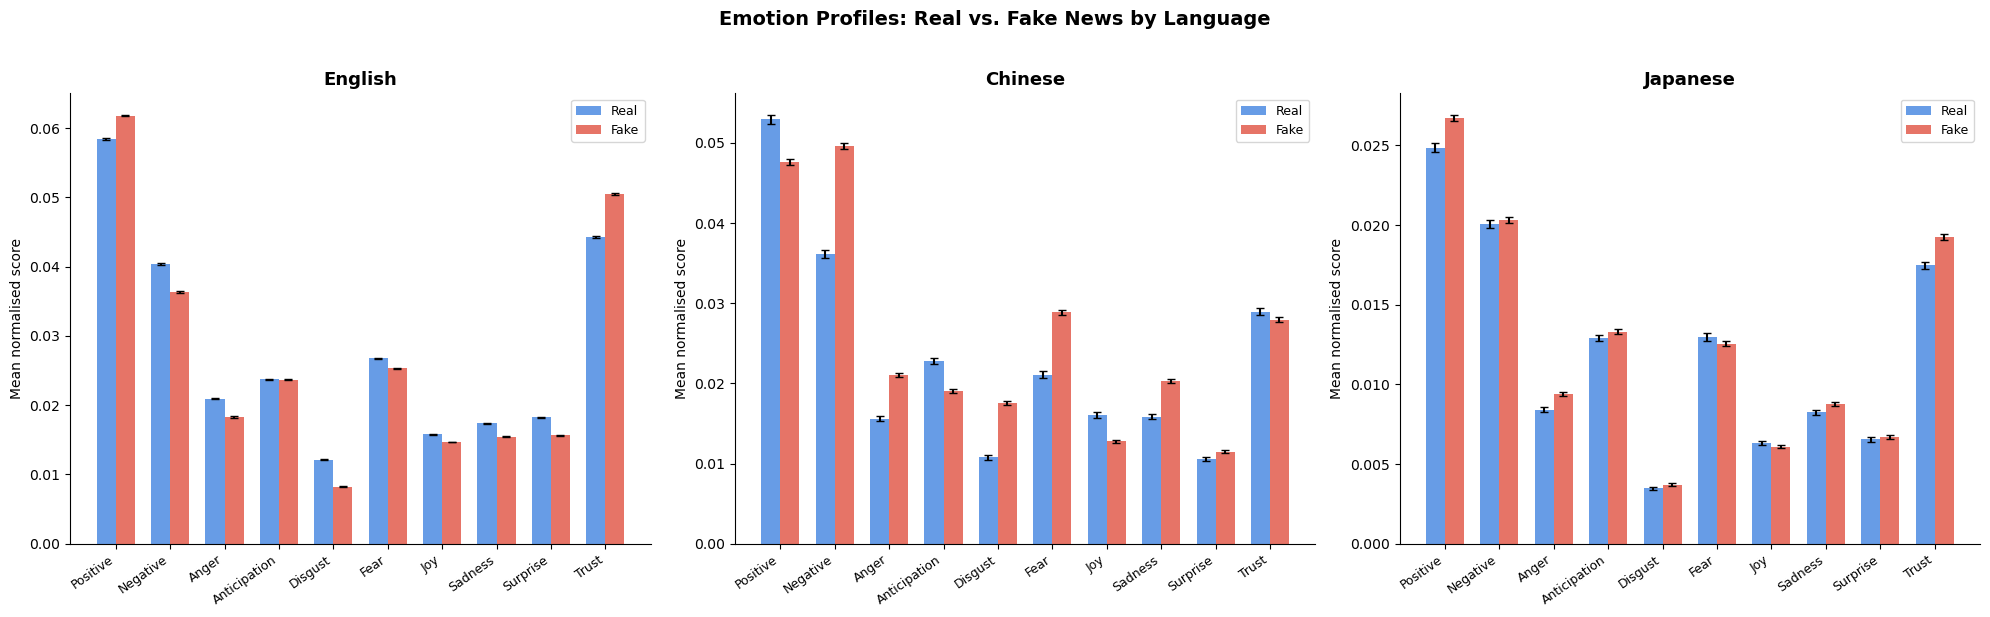

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

colors = {'real': '#4C8BE2', 'fake': '#E25C4C'}
x = np.arange(len(EMOTIONS))
width = 0.35

for ax, (lang, tbl) in zip(axes, agg_tables.items()):
    # bars
    bars_real = ax.bar(x - width/2, tbl['real_mean'], width,
                   yerr=tbl['real_sem'], capsize=3,
                   color=colors['real'], alpha=0.85, label='Real')
    bars_fake = ax.bar(x + width/2, tbl['fake_mean'], width,
                   yerr=tbl['fake_sem'], capsize=3,
                   color=colors['fake'], alpha=0.85, label='Fake')

    ax.set_title(lang, fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right', fontsize=9)
    ax.set_ylabel('Mean normalised score')
    ax.legend(fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emotion Profiles: Real vs. Fake News by Language',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('emotion_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical Analyses

In [57]:
from scipy.stats import skew, kurtosis

for lang, df in scored.items():
    print(f"\n── {lang} ──")
    rows = []
    for emotion in EMOTIONS:
        for label, name in [(0, 'real'), (1, 'fake')]:
            vals = df[df['label'] == label][emotion]
            rows.append({
                'emotion': emotion,
                'group': name,
                'skewness': round(skew(vals), 3),
                'kurtosis': round(kurtosis(vals), 3),  # excess kurtosis, 0=normal
                'zero_pct': round((vals == 0).mean() * 100, 1)
            })
    print(pd.DataFrame(rows).to_string(index=False))


── English ──
     emotion group  skewness  kurtosis  zero_pct
    Positive  real     4.931    66.639       0.0
    Positive  fake     1.504     5.126       0.0
    Negative  real     2.163    13.939       4.3
    Negative  fake     0.957     2.390       2.4
       Anger  real     2.771    19.854       9.3
       Anger  fake     1.742     6.403       8.3
Anticipation  real     3.878    44.587       6.5
Anticipation  fake     1.723     7.383       3.4
     Disgust  real     4.697    52.785      15.2
     Disgust  fake     2.492    13.249      17.9
        Fear  real     2.371    17.835       6.9
        Fear  fake     1.542     4.463       5.5
         Joy  real     4.574    59.972      10.7
         Joy  fake     1.994     8.042       8.0
     Sadness  real     2.871    21.143      10.6
     Sadness  fake     1.773     6.168       9.5
    Surprise  real     2.541    14.521      11.0
    Surprise  fake     1.669     5.271       8.3
       Trust  real     6.309    97.867       0.0
     

C:\Users\acl13\AppData\Local\Temp\ipykernel_53148\4150972924.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\acl13\AppData\Local\Temp\ipykernel_53148\4150972924.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
C:\Users\acl13\AppData\Local\Temp\ipykernel_53148\4150972924.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\acl13\AppData\Local\Temp\ipykernel_53148\4150972924.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
C:\Users\acl13\AppData\Local\Temp\ipykernel_53148\

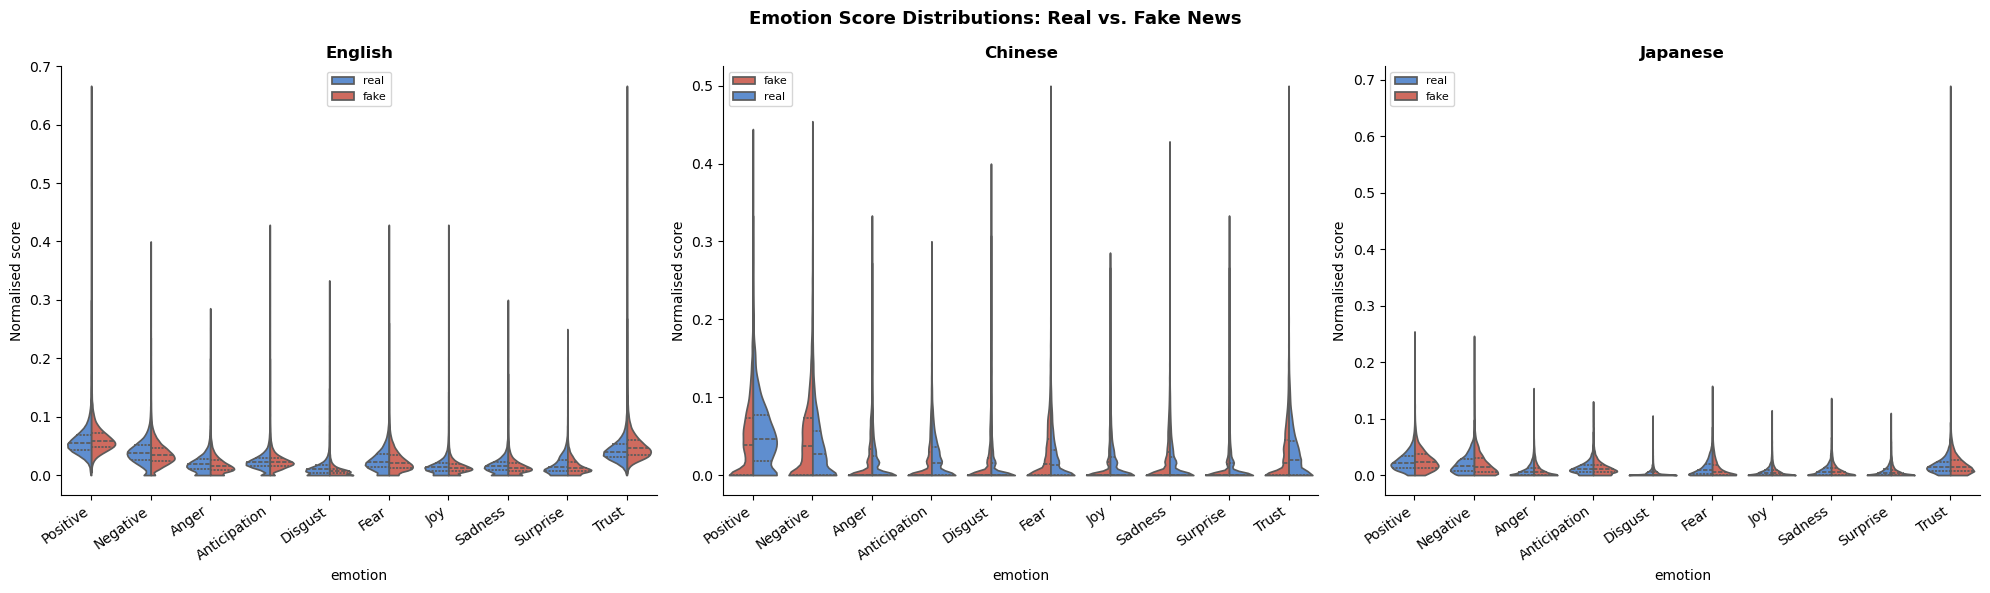

In [59]:
# violin plot that summarizes distributions

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (lang, df) in zip(axes, scored.items()):
    # melt to long format for seaborn
    long = df[['label'] + EMOTIONS].melt(
        id_vars='label',
        var_name='emotion',
        value_name='score'
    )
    long['group'] = long['label'].map({0: 'real', 1: 'fake'})

    sns.violinplot(
        data=long, x='emotion', y='score', hue='group',
        ax=ax, split=True, inner='quart',
        palette={'real': '#4C8BE2', 'fake': '#E25C4C'},
        scale='width', cut=0  # cut=0 stops violins extending below 0
    )
    ax.set_title(lang, fontweight='bold')
    ax.set_xticklabels(EMOTIONS, rotation=35, ha='right')
    ax.set_ylabel('Normalised score')
    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Emotion Score Distributions: Real vs. Fake News',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('emotion_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [55]:
# lack of normality rules out T-test
# conduct Mann-Whitney U test instead
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

stats_results = {}

for lang, df in scored.items():
    real = df[df['label'] == 0]
    fake = df[df['label'] == 1]
    
    rows = []
    for emotion in EMOTIONS:
        stat, p = mannwhitneyu(fake[emotion], real[emotion], alternative='two-sided')
        r = 1 - (2 * stat) / (len(fake) * len(real))
        rows.append({
            'emotion': emotion,
            'mean_real': real[emotion].mean(),
            'mean_fake': fake[emotion].mean(),
            'U_stat': stat,
            'p_value': p,
            'effect_r': round(r, 4)
        })
    
    lang_df = pd.DataFrame(rows)
    
    # FDR correction across 10 emotions within this language
    rejected, p_fdr, _, _ = multipletests(lang_df['p_value'], method='fdr_bh')
    lang_df['p_fdr'] = p_fdr
    lang_df['significant'] = rejected
    
    stats_results[lang] = lang_df.set_index('emotion')
    print(f"\n── {lang} ──")
    print(lang_df.set_index('emotion').round(5))



── English ──
              mean_real  mean_fake       U_stat  p_value  effect_r    p_fdr  \
emotion                                                                       
Positive        0.05839    0.06181  727517474.5  0.00000   -0.1195  0.00000   
Negative        0.04035    0.03635  580448202.5  0.00000    0.1068  0.00000   
Anger           0.02094    0.01829  584553424.5  0.00000    0.1005  0.00000   
Anticipation    0.02372    0.02370  658467448.0  0.00211   -0.0132  0.00211   
Disgust         0.01216    0.00825  512501835.0  0.00000    0.2114  0.00000   
Fear            0.02676    0.02534  619112877.5  0.00000    0.0473  0.00000   
Joy             0.01583    0.01469  634270588.0  0.00000    0.0240  0.00000   
Sadness         0.01739    0.01542  598307666.5  0.00000    0.0793  0.00000   
Surprise        0.01827    0.01568  611799923.5  0.00000    0.0586  0.00000   
Trust           0.04427    0.05047  766831911.5  0.00000   -0.1800  0.00000   

              significant  
emotion 

EN: all significant. 
Effect sizes large to small: (neglected the ones smaller than .1)
* disgust (.21)
* trust (-.18)
* positive (-.11)
* negative (.11)
* anger (.1)

CN: all significant.
Effect sizes large to small: 
* anticipation (.13)
* joy (.12)
* negative (-.12)
* positive (.10)

JP: all significant except anger & trust
Effect sizes large to small:
* fear (.08) 
the rest are too small. 
